In [1]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import datetime as dt
from datetime import datetime    
sns.set_style("whitegrid")
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("ggplot")

In [2]:
import requests
import csv
from tqdm import tqdm
import os

In [3]:
import zipfile

zip_file = 'archive.zip'   # replace with your file name

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('data_folder')

In [4]:
os.listdir('data_folder')

['ADANIPORTS.csv',
 'ASIANPAINT.csv',
 'AXISBANK.csv',
 'BAJAJ-AUTO.csv',
 'BAJAJFINSV.csv',
 'BAJFINANCE.csv',
 'BHARTIARTL.csv',
 'BPCL.csv',
 'BRITANNIA.csv',
 'CIPLA.csv',
 'COALINDIA.csv',
 'DRREDDY.csv',
 'EICHERMOT.csv',
 'GAIL.csv',
 'GRASIM.csv',
 'HCLTECH.csv',
 'HDFC.csv',
 'HDFCBANK.csv',
 'HEROMOTOCO.csv',
 'HINDALCO.csv',
 'HINDUNILVR.csv',
 'ICICIBANK.csv',
 'INDUSINDBK.csv',
 'INFRATEL.csv',
 'INFY.csv',
 'IOC.csv',
 'ITC.csv',
 'JSWSTEEL.csv',
 'KOTAKBANK.csv',
 'LT.csv',
 'MARUTI.csv',
 'MM.csv',
 'NESTLEIND.csv',
 'NIFTY50_all.csv',
 'NTPC.csv',
 'ONGC.csv',
 'POWERGRID.csv',
 'RELIANCE.csv',
 'SBIN.csv',
 'SHREECEM.csv',
 'stock_metadata.csv',
 'SUNPHARMA.csv',
 'TATAMOTORS.csv',
 'TATASTEEL.csv',
 'TCS.csv',
 'TECHM.csv',
 'TITAN.csv',
 'ULTRACEMCO.csv',
 'UPL.csv',
 'VEDL.csv',
 'WIPRO.csv',
 'ZEEL.csv']

In [5]:

folder_path = 'data_folder'

files = os.listdir(folder_path)

dataframes = []

for file in files:
    if file.endswith('.csv') and file != 'stock_metadata.csv':
        df = pd.read_csv(f'{folder_path}/{file}')
        
        df['Company'] = file.replace('.csv', '')   # Add company name
        
        dataframes.append(df)

In [6]:
df = pd.concat(dataframes, ignore_index=True)

C:\Users\Lalit Karki\AppData\Local\Temp\ipykernel_9196\1410112375.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dataframes, ignore_index=True)


In [7]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Company
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612,ADANIPORTS
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172,ADANIPORTS
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088,ADANIPORTS
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735,ADANIPORTS
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741,ADANIPORTS


In [8]:
df.shape

(470384, 16)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470384 entries, 0 to 470383
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Date                470384 non-null  object 
 1   Symbol              470384 non-null  object 
 2   Series              470384 non-null  object 
 3   Prev Close          470384 non-null  float64
 4   Open                470384 non-null  float64
 5   High                470384 non-null  float64
 6   Low                 470384 non-null  float64
 7   Last                470384 non-null  float64
 8   Close               470384 non-null  float64
 9   VWAP                470384 non-null  float64
 10  Volume              470384 non-null  object 
 11  Turnover            470384 non-null  float64
 12  Trades              240688 non-null  float64
 13  Deliverable Volume  438230 non-null  float64
 14  %Deliverble         438230 non-null  float64
 15  Company             470384 non-nul

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

In [11]:
df = df.sort_values(by=['Company', 'Date'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 470384 entries, 0 to 470383
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                470384 non-null  datetime64[ns]
 1   Symbol              470384 non-null  object        
 2   Series              470384 non-null  object        
 3   Prev Close          470384 non-null  float64       
 4   Open                470384 non-null  float64       
 5   High                470384 non-null  float64       
 6   Low                 470384 non-null  float64       
 7   Last                470384 non-null  float64       
 8   Close               470384 non-null  float64       
 9   VWAP                470384 non-null  float64       
 10  Volume              470384 non-null  object        
 11  Turnover            470384 non-null  float64       
 12  Trades              240688 non-null  float64       
 13  Deliverable Volume  438230 non-nul

In [13]:
df['Volume'] = df['Volume'].astype(str).str.replace(',', '')
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

In [14]:
df.isnull().sum()

Date                       0
Symbol                     0
Series                     0
Prev Close                 0
Open                       0
High                       0
Low                        0
Last                       0
Close                      0
VWAP                       0
Volume                     0
Turnover                   0
Trades                229696
Deliverable Volume     32154
%Deliverble            32154
Company                    0
dtype: int64

In [15]:
df['Trades'].fillna(df['Trades'].median(), inplace=True)
df['Deliverable Volume'].fillna(df['Deliverable Volume'].median(), inplace=True)
df['%Deliverble'].fillna(df['%Deliverble'].median(), inplace=True)

C:\Users\Lalit Karki\AppData\Local\Temp\ipykernel_9196\3738027212.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Trades'].fillna(df['Trades'].median(), inplace=True)
C:\Users\Lalit Karki\AppData\Local\Temp\ipykernel_9196\3738027212.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [16]:
df = df.sort_values(by=['Company', 'Date'])

In [17]:
df['Return'] = df.groupby('Company')['Close'].pct_change()

In [18]:
df['MA_7'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(7).mean())
df['MA_30'] = df.groupby('Company')['Close'].transform(lambda x: x.rolling(30).mean())

In [19]:
df['Target'] = df.groupby('Company')['Close'].shift(-1)

In [20]:
df = df.dropna()

In [21]:
# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

In [22]:
# Moving Averages
for ma in [10, 50, 100]:
    df[f'MA_{ma}'] = df['Close'].rolling(window=ma).mean()

# Daily Return
df['Daily_Return'] = df['Close'].pct_change()


#  VISUALIZATION

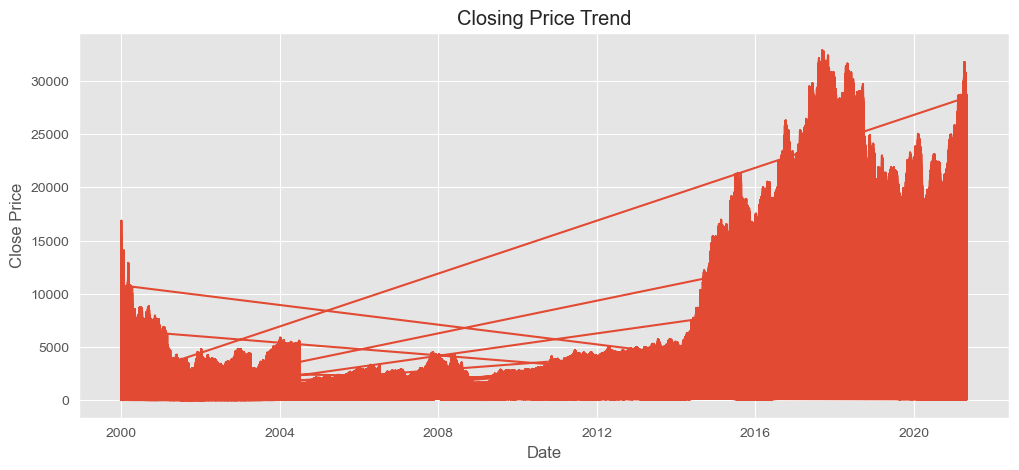

In [23]:
# Closing Price Trend
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'])
plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

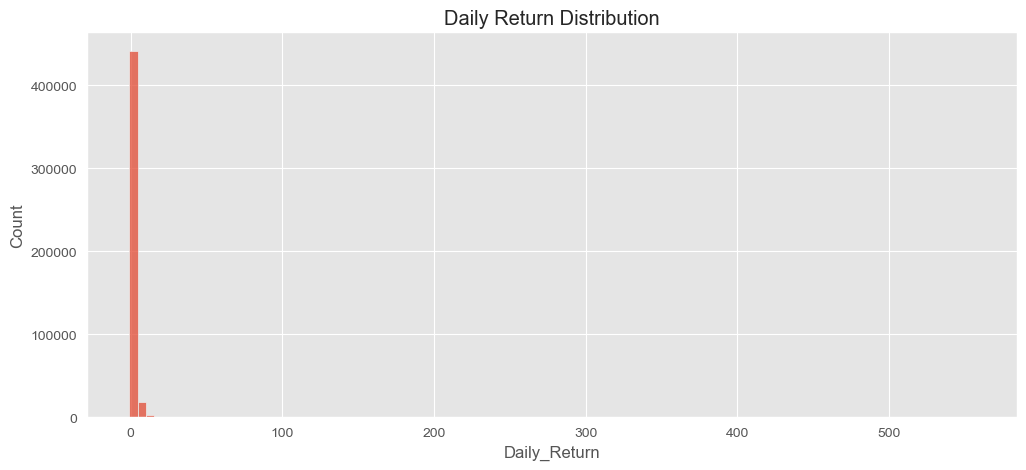

In [24]:
# Daily Return Distribution

plt.figure(figsize=(12,5))
sns.histplot(df['Daily_Return'], bins=100)
plt.title("Daily Return Distribution")
plt.show()

In [25]:
# Key Features Plot
cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_10', 'MA_50', 'MA_100']

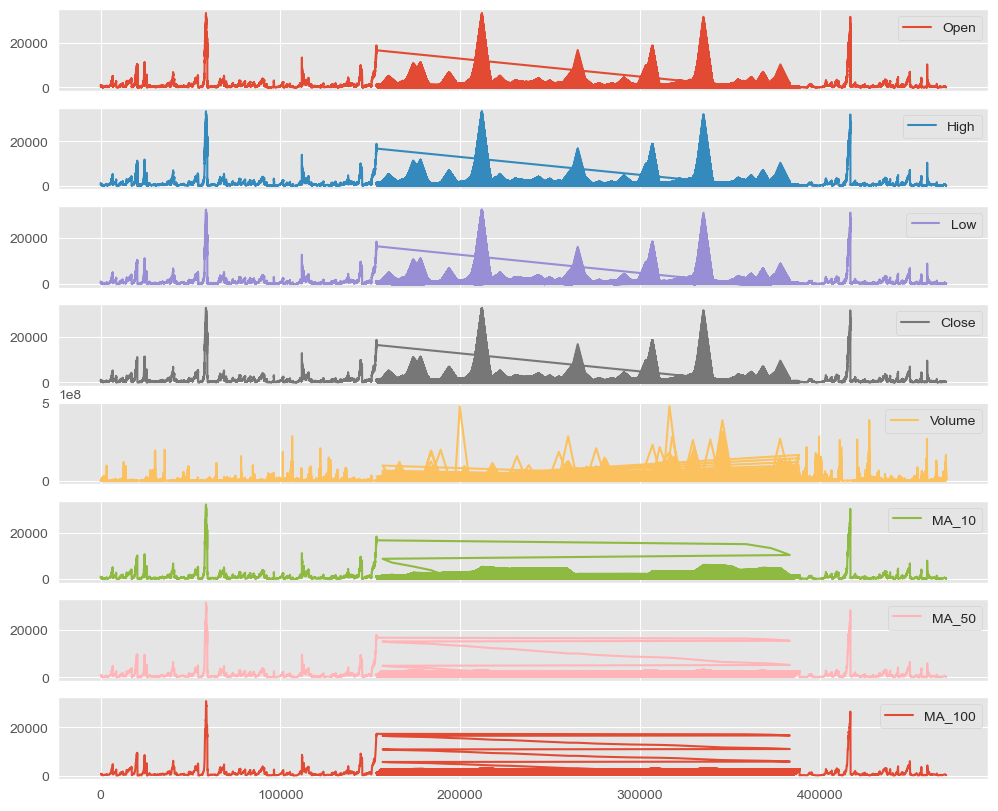

In [26]:
df[cols].plot(subplots=True, figsize=(12,10))
plt.show()

In [27]:
#  FINAL CHECK
print(df.describe().T)

                       count                           mean  \
Date                  468884  2011-06-01 20:28:21.217358848   
Prev Close          468884.0                     1267.30275   
Open                468884.0                    1268.854632   
High                468884.0                    1287.659813   
Low                 468884.0                    1248.606492   
Last                468884.0                    1267.489001   
Close               468884.0                    1267.654887   
VWAP                468884.0                    1268.227563   
Volume              468884.0                 3044379.368916   
Turnover            468884.0          161179991473014.03125   
Trades              468884.0                   53243.604346   
Deliverable Volume  468884.0                 1259166.260529   
%Deliverble         468884.0                       0.503605   
Return              468884.0                       1.343142   
MA_7                468884.0                      1267.

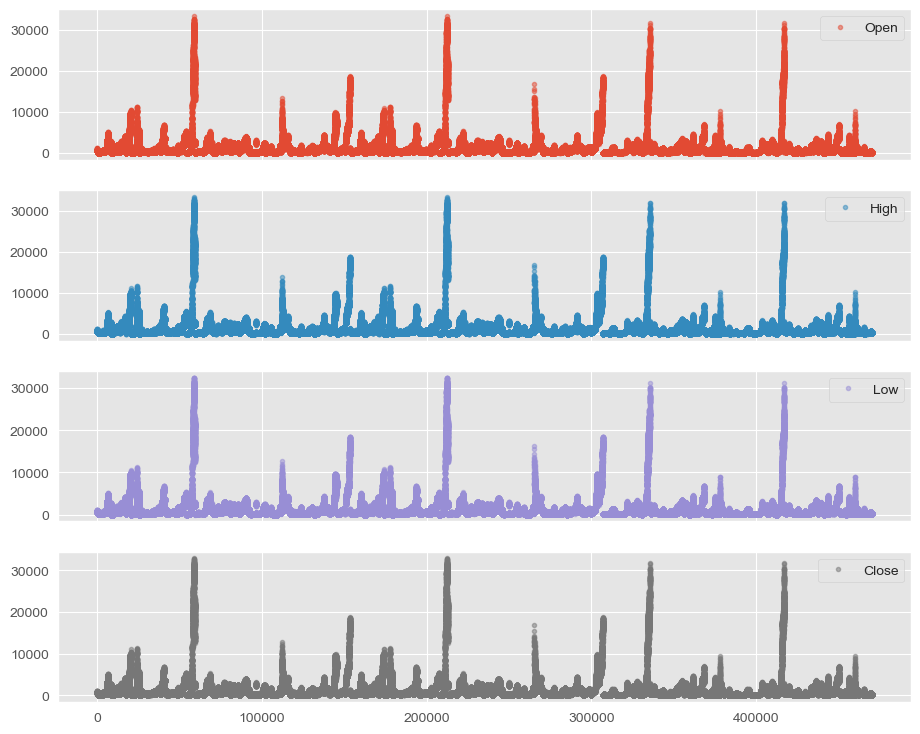

In [28]:
cols_plot = ['Open', 'High', 'Low','Close']
axes = df[cols_plot].plot(marker='.', alpha=0.5, linestyle='None', figsize=(11, 9), subplots=True)

             Date      Symbol Series  Prev Close    Open     High      Low  \
29     2008-01-09  MUNDRAPORT     EQ     1204.80  1200.0  1210.00  1151.00   
30     2008-01-10  MUNDRAPORT     EQ     1180.25  1185.0  1199.80  1110.00   
31     2008-01-11  MUNDRAPORT     EQ     1121.55  1128.0  1130.00  1063.00   
32     2008-01-14  MUNDRAPORT     EQ     1085.85  1082.4  1082.40  1031.10   
33     2008-01-15  MUNDRAPORT     EQ     1035.15  1045.6  1078.70  1036.05   
...           ...         ...    ...         ...     ...      ...      ...   
470378 2021-04-23        ZEEL     EQ      192.30   192.0   193.00   187.00   
470379 2021-04-26        ZEEL     EQ      188.00   190.6   191.10   185.10   
470380 2021-04-27        ZEEL     EQ      186.40   188.0   192.95   186.80   
470381 2021-04-28        ZEEL     EQ      188.15   188.8   190.60   187.10   
470382 2021-04-29        ZEEL     EQ      189.10   190.8   191.65   186.00   

           Last    Close     VWAP  ...  %Deliverble     Company

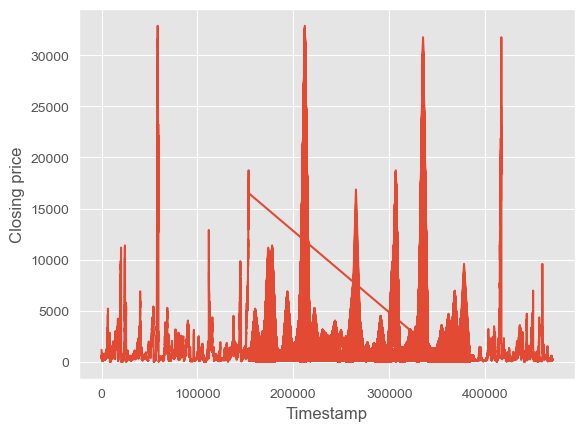

In [29]:
plt.plot(df['Close'], label="Close price")
plt.xlabel("Timestamp")
plt.ylabel("Closing price")
print(df)

In [30]:
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
Date,468884,2011-06-01 20:28:21.217358848,2000-01-03 00:00:00,2006-07-18 00:00:00,2011-08-30 00:00:00,2016-06-29 00:00:00,2021-04-30 00:00:00,NaN
Prev Close,468884.0,1267.30275,0.0,274.75,567.45,1243.25,32861.95,2583.007822
Open,468884.0,1268.854632,8.5,275.0,568.0,1244.9125,33399.95,2586.937192
High,468884.0,1287.659813,9.75,279.9,577.5,1264.2,33480.0,2621.298481
Low,468884.0,1248.606492,8.5,270.05,557.15,1223.2,32468.1,2548.323789
Last,468884.0,1267.489001,9.1,274.95,567.8,1244.0,32849.0,2583.068421
Close,468884.0,1267.654887,9.15,274.8,567.5,1243.55,32861.95,2583.817206
VWAP,468884.0,1268.227563,9.21,275.11,567.64,1243.705,32975.24,2584.370494
Volume,468884.0,3044379.368916,3.0,220765.0,1014299.0,3024343.25,481058927.0,7255406.761072
Turnover,468884.0,161179991473014.03125,10470000.0,16296999119999.998047,68560752995000.007812,186681419925000.0,35643341676765004.0,329142979182063.875


In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X = []
y = []
window_size=100

In [33]:
# Using Close price column
close_prices = df['Close'].values

for i in range(len(close_prices) - window_size):

    # Select 100-day window
    window = close_prices[i:i + window_size]

    # Target = next day price
    target = close_prices[i + window_size]

    # Normalize data
    normalized_window = (window - window[0]) / window[0]
    normalized_target = (target - window[0]) / window[0]

    # Store values
    X.append(normalized_window)
    y.append(normalized_target)

# Convert to NumPy arrays
X = np.array(X)
y = np.array(y)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)

In [35]:
X_train = X_train.reshape(X_train.shape[0], 100, 1)
X_test = X_test.reshape(X_test.shape[0], 100, 1)

In [36]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape :", y_test.shape)

Training Data Shape: (375027, 100, 1)
Testing Data Shape : (93757, 100, 1)
Training Labels Shape: (375027,)
Testing Labels Shape : (93757,)


# Training 

In [37]:
!pip install tensorflow

In [38]:
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, LSTM, Dense , Dropout 
from tensorflow.keras.layers import MaxPooling1D, Flatten
from tensorflow.keras.regularizers import L1, L2
from tensorflow.keras.metrics import Accuracy ,RootMeanSquaredError

In [39]:
print(X_train.shape)
print(X_test.shape)

(375027, 100, 1)
(93757, 100, 1)


In [40]:
from tensorflow.keras.models import Sequential

In [41]:
# BUILD CNN + LSTM HYBRID MODEL

model = Sequential()

In [42]:
# ----- CNN Layer -----
model.add(Conv1D(filters=64,kernel_size=3,activation='relu',input_shape=(100,1)))

# ----- Pooling Layer -----
model.add(MaxPooling1D(pool_size=2))

# ----- Dropout -----
model.add(Dropout(0.2))

# ----- LSTM Layer -----
model.add(LSTM(50))

# ----- Dense Layers -----
model.add(Dense(50, activation='relu'))

model.add(Dense(1))


C:\Users\Lalit Karki\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae'])

In [44]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 98, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 49, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 49, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 50)                  │          23,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,857 (101.00 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=40,
    verbose=1,
    shuffle=False)

Epoch 1/10
9376/9376 ━━━━━━━━━━━━━━━━━━━━ 287s 27ms/step - loss: 16.9164 - mae: 1.0702 - val_loss: 5.2381 - val_mae: 0.5893
Epoch 2/10
9376/9376 ━━━━━━━━━━━━━━━━━━━━ 250s 27ms/step - loss: 4.6602 - mae: 0.6217 - val_loss: 2.4631 - val_mae: 0.4393
Epoch 3/10
9376/9376 ━━━━━━━━━━━━━━━━━━━━ 250s 27ms/step - loss: 3.1263 - mae: 0.5256 - val_loss: 1.2399 - val_mae: 0.3959
Epoch 4/10
9376/9376 ━━━━━━━━━━━━━━━━━━━━ 265s 27ms/step - loss: 1.9583 - mae: 0.4502 - val_loss: 0.8274 - val_mae: 0.3406
Epoch 5/10
9376/9376 ━━━━━━━━━━━━━━━━━━━━ 253s 27ms/step - loss: 1.6850 - mae: 0.4120 - val_loss: 0.7761 - val_mae: 0.3134
Epoch 6/10
9376/9376 ━━━━━━━━━━━━━━━━━━━━ 265s 27ms/step - loss: 1.4910 - mae: 0.3844 - val_loss: 0.7540 - val_mae: 0.3132
Epoch 7/10
9376/9376 ━━━━━━━━━━━━━━━━━━━━ 400s 43ms/step - loss: 1.4413 - mae: 0.3720 - val_loss: 0.7736 - val_mae: 0.3043
Epoch 8/10
9376/9376 ━━━━━━━━━━━━━━━━━━━━ 431s 41ms/step - loss: 1.4260 - mae: 0.3625 - val_loss: 0.6747 - val_mae: 0.2948
Epoch 9/10
9376

In [46]:
predictions = model.predict(X_test)

2930/2930 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [48]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)

MAE  : 0.2740761013341476
MSE  : 0.5763801735552075
RMSE : 0.7591970584474149


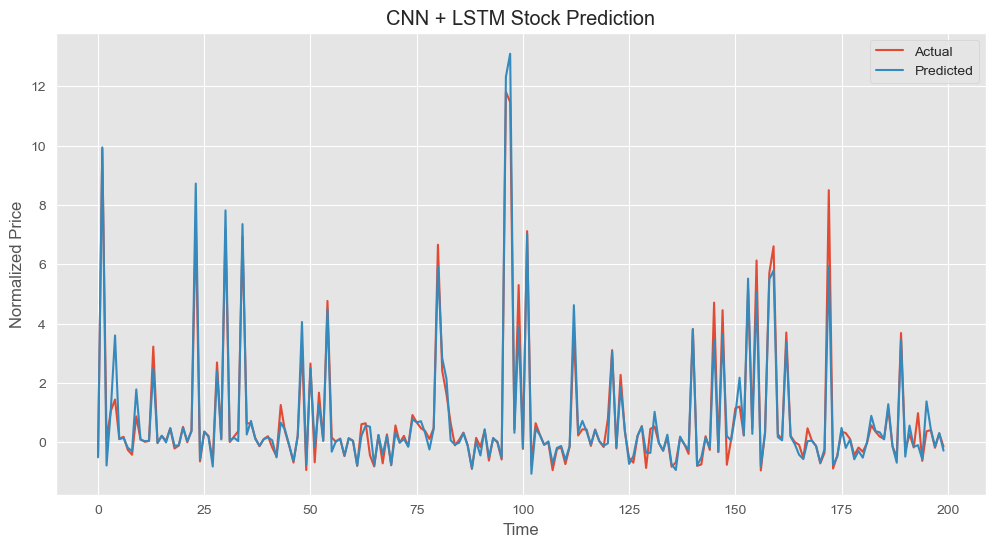

In [49]:
plt.figure(figsize=(12,6))
plt.plot(y_test[:200], label='Actual')
plt.plot(predictions[:200], label='Predicted')
plt.title("CNN + LSTM Stock Prediction")
plt.xlabel("Time")
plt.ylabel("Normalized Price")
plt.legend()
plt.show()

In [50]:
stocks = ['RELIANCE', 'TCS', 'INFY', 'HDFCBANK']

for stock in stocks:

    stock_data = df[df['Company'] == stock]

    close_prices = stock_data['Close'].values

    X_stock = []
    y_stock = []



In [51]:
for i in range(len(close_prices) - 100):

    window = close_prices[i:i+100]
    target = close_prices[i+100]

    normalized_window = (window - window[0]) / window[0]
    normalized_target = (target - window[0]) / window[0]

    X_stock.append(normalized_window)
    y_stock.append(normalized_target)

In [52]:
X_stock = np.array(X_stock)
y_stock = np.array(y_stock)

X_stock = X_stock.reshape(X_stock.shape[0], 100, 1)

predictions = model.predict(X_stock)

    

162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


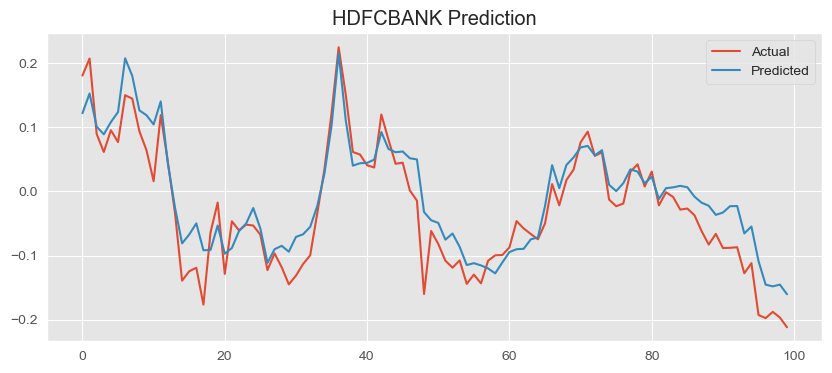

In [53]:
# Plot
plt.figure(figsize=(10,4))
plt.plot(y_stock[:100], label='Actual')
plt.plot(predictions[:100], label='Predicted')
plt.title(f'{stock} Prediction')
plt.legend()
plt.show()

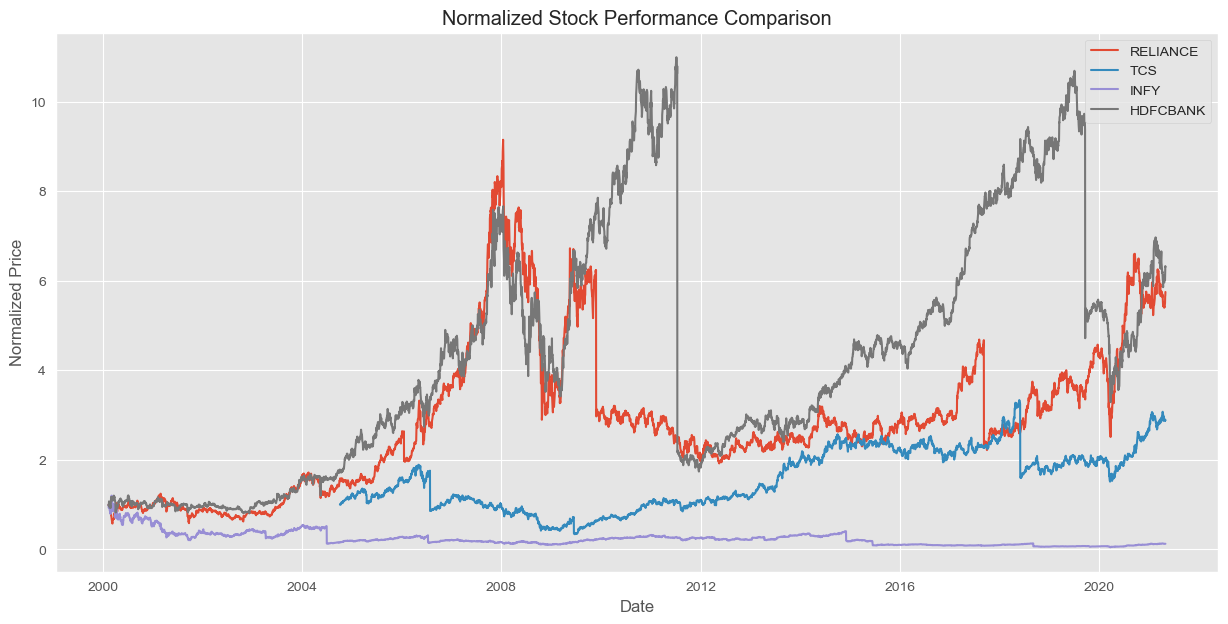

In [54]:
stocks = ['RELIANCE', 'TCS', 'INFY', 'HDFCBANK']

plt.figure(figsize=(15,7))

for stock in stocks:

    stock_data = df[df['Company'] == stock].copy()

    # Normalize prices
    stock_data['Normalized_Close'] = (
        stock_data['Close'] / stock_data['Close'].iloc[0] )

    plt.plot(
        stock_data['Date'],
        stock_data['Normalized_Close'],
        label=stock )

plt.title("Normalized Stock Performance Comparison")
plt.xlabel("Date")
plt.ylabel("Normalized Price")

plt.legend()
plt.grid(True)

plt.show()

In [55]:
# Calculate the daily Retuen
df['Daily_Return'] = df.groupby('Company')['Close'].pct_change()

In [56]:
# Calculate Volatility
volatility = df.groupby('Company')['Daily_Return'].std()

volatility = volatility.sort_values()

print(volatility)

Company
NESTLEIND       0.015256
POWERGRID       0.018405
COALINDIA       0.018774
NTPC            0.019062
ULTRACEMCO      0.020972
BRITANNIA       0.021046
BAJAJ-AUTO      0.021204
MARUTI          0.021701
ASIANPAINT      0.022306
HINDUNILVR      0.022477
DRREDDY         0.023115
HDFCBANK        0.023801
TCS             0.023806
RELIANCE        0.023975
CIPLA           0.024306
SHREECEM        0.024363
ITC             0.024407
HEROMOTOCO      0.024410
BAJAJFINSV      0.024765
GRASIM          0.024822
BHARTIARTL      0.025189
GAIL            0.025369
LT              0.025762
HDFC            0.026042
ONGC            0.026199
IOC             0.026480
SBIN            0.026786
MM              0.027654
TATASTEEL       0.027794
TECHM           0.028043
SUNPHARMA       0.029011
INFY            0.029129
BPCL            0.029426
HINDALCO        0.029564
ICICIBANK       0.029710
UPL             0.030071
EICHERMOT       0.030123
ADANIPORTS      0.030280
WIPRO           0.030325
AXISBANK        0

In [57]:
stable_stocks = volatility.head(10)

print("Stable Stocks:")
print(stable_stocks)

Stable Stocks:
Company
NESTLEIND     0.015256
POWERGRID     0.018405
COALINDIA     0.018774
NTPC          0.019062
ULTRACEMCO    0.020972
BRITANNIA     0.021046
BAJAJ-AUTO    0.021204
MARUTI        0.021701
ASIANPAINT    0.022306
HINDUNILVR    0.022477
Name: Daily_Return, dtype: float64


In [58]:
volatile_stocks = volatility.tail(10)

print("Volatile Stocks:\n")
print(volatile_stocks)

Volatile Stocks:

Company
BAJFINANCE      0.030534
TATAMOTORS      0.030638
TITAN           0.031463
INDUSINDBK      0.031768
HCLTECH         0.032335
KOTAKBANK       0.032503
JSWSTEEL        0.032994
ZEEL            0.033054
VEDL            0.035848
NIFTY50_all    15.646402
Name: Daily_Return, dtype: float64


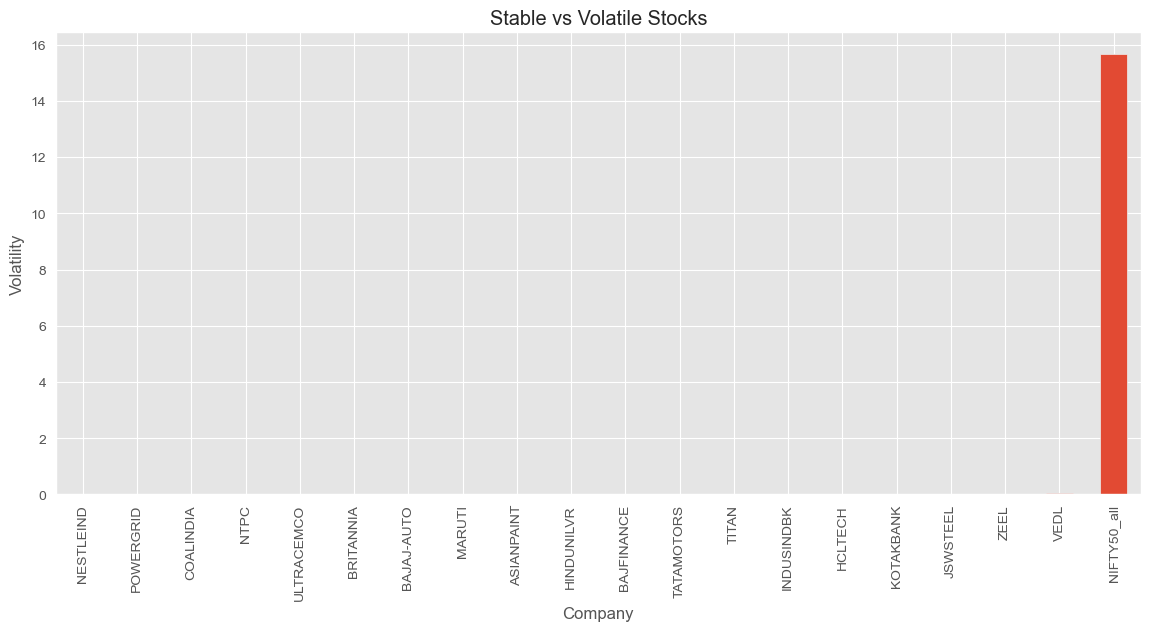

In [59]:
# Visualize Stable vs Volatile Stocks
# Combine both
selected_stocks = pd.concat([stable_stocks,volatile_stocks])

# Plot
plt.figure(figsize=(14,6))
selected_stocks.plot(kind='bar')
plt.title("Stable vs Volatile Stocks")
plt.xlabel("Company")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()